In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env


# ==================== Custom Projectile Environment ====================
class Projectile1DEnv(gym.Env):
    """
    Environment for 1D Projectile Motion
    """    
    def __init__(self):
        super().__init__()
        
        # Physics parameters
        self.g = 9.81
        self.max_distance = 100.0
        self.max_angle = 89.0
        self.min_angle = 1.0
        self.max_force = 50.0
        self.min_force = 5.0
        self.tolerance = 0.5 # in meters around target for success
        
        
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(1,), dtype=np.float32
        ) # Normalized target distance
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(2,), dtype=np.float32
        ) # Normalized angle and force
        
        self.target_distance = 0.0
    
    def reset(self, seed=None, options=None):
        """Reset environment with new random target"""
        super().reset(seed=seed)
        
        self.target_distance = np.random.uniform(10.0, self.max_distance)
        obs = np.array([self.target_distance / self.max_distance], dtype=np.float32)
        
        return obs, {}
    
    def calculate_distance(self, angle_deg, force):
        """Physics: R = (v² * sin(2θ)) / g"""
        angle_rad = np.deg2rad(angle_deg)
        return (force**2 * np.sin(2 * angle_rad)) / self.g
    
    def step(self, action):
        """Execute action and return reward"""
        angle_norm, force_norm = action
        angle = self.min_angle + (angle_norm + 1) / 2 * (self.max_angle - self.min_angle)
        force = self.min_force + (force_norm + 1) / 2 * (self.max_force - self.min_force)
        
        angle = np.clip(angle, self.min_angle, self.max_angle)
        force = np.clip(force, self.min_force, self.max_force)
        
        # Calculate projectile distance
        actual_distance = self.calculate_distance(angle, force)
        error = abs(actual_distance - self.target_distance)
        
        # Exponential reward (provides gradient even when far from target)
        distance_reward = np.exp(-error / 10.0) * 10
        
        # Bonuses
        if error < self.tolerance:
            success_bonus = 5.0  # Hit the target!
        elif error < 1.0:
            success_bonus = 2.0  # Very close
        elif error < 3.0:
            success_bonus = 1.0   # Close
        else:
            success_bonus = 0.0
        
        # Penalty for very poor performance
        penalty = -5.0 if error > 50.0 else 0.0
        
        reward = float(distance_reward + success_bonus + penalty)
        
        # Episode ends after one shot
        terminated = True
        truncated = False
        
        obs = np.array([self.target_distance / self.max_distance], dtype=np.float32)
        info = {
            'angle': float(angle),
            'force': float(force),
            'actual_distance': float(actual_distance),
            'target_distance': float(self.target_distance),
            'error': float(error),
            'success': bool(error < self.tolerance)
        }
        
        return obs, reward, terminated, truncated, info

In [ ]:
# ==================== Callback for Tracking ====================
class TrackingCallback(BaseCallback):
    """
    Callback to track training metrics with early stopping and best model saving
    """
    def __init__(self, check_freq=500, patience=5000, min_success_rate=95.0, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_errors = []
        self.episode_successes = []
        self.episode_count = 0
        
        # Early stopping parameters
        self.check_freq = check_freq
        self.patience = patience  # Number of episodes without improvement
        self.min_success_rate = min_success_rate  # Target success rate
        self.best_success_rate = 0.0
        self.best_mean_reward = -np.inf
        self.episodes_without_improvement = 0
        self.converged = False
        
    def _on_step(self) -> bool:
        # Get info from environment
        for info in self.locals.get('infos', []):
            if 'error' in info:
                self.episode_rewards.append(self.locals['rewards'][0])
                self.episode_errors.append(info['error'])
                self.episode_successes.append(1 if info['success'] else 0)
                self.episode_count += 1
                
                # Check for improvement every check_freq episodes
                if self.episode_count % self.check_freq == 0:
                    window = min(self.check_freq, len(self.episode_rewards))
                    avg_reward = np.mean(self.episode_rewards[-window:])
                    avg_error = np.mean(self.episode_errors[-window:])
                    success_rate = np.mean(self.episode_successes[-window:]) * 100
                    
                    print(f"Episode {self.episode_count:5d} | "
                          f"Reward: {avg_reward:7.2f} | "
                          f"Error: {avg_error:6.2f}m | "
                          f"Success: {success_rate:5.1f}%")
                    
                    # Check if this is the best model so far
                    improved = False
                    if success_rate > self.best_success_rate:
                        self.best_success_rate = success_rate
                        improved = True
                    elif success_rate == self.best_success_rate and avg_reward > self.best_mean_reward:
                        improved = True
                    
                    if improved:
                        self.best_mean_reward = avg_reward
                        self.episodes_without_improvement = 0
                        # Save best model
                        self.model.save("projectile_best_model")
                        print(f"New best model saved! (Success: {success_rate:.1f}%)")
                    else:
                        self.episodes_without_improvement += self.check_freq
                    
                    # Check convergence criteria
                    if success_rate >= self.min_success_rate:
                        print(f"\n{'='*70}")
                        print("CONVERGENCE ACHIEVED!")
                        print(f"  Target success rate {self.min_success_rate}% reached: {success_rate:.1f}%")
                        print(f"  Stopping training early at episode {self.episode_count}")
                        print(f"{'='*70}\n")
                        self.converged = True
                        return False  # Stop training
                    
                    # Check early stopping
                    if self.episodes_without_improvement >= self.patience:
                        print(f"\n{'='*70}")
                        print("EARLY STOPPING TRIGGERED")
                        print(f"  No improvement for {self.patience} episodes")
                        print(f"  Best success rate: {self.best_success_rate:.1f}%")
                        print(f"  Stopping training at episode {self.episode_count}")
                        print(f"{'='*70}\n")
                        self.converged = True
                        return False  # Stop training
        
        return True


# ==================== Training Function ====================
def train_projectile(total_timesteps=50000, check_freq=500, patience=5000, target_success_rate=95.0):
    """
    Train PPO agent on projectile environment with early stopping
    
    Args:
        total_timesteps: Maximum number of timesteps to train
        check_freq: How often to check for improvement (in episodes)
        patience: Stop if no improvement for this many episodes
        target_success_rate: Target success rate for convergence (%)
    """
    print("=" * 70)
    print("PPO FOR 1D PROJECTILE MOTION - STABLE-BASELINES3")
    print("=" * 70)
    print()
    
    # Create environment
    env = Projectile1DEnv()

    
    # Create agent
    print("Creating PPO agent...")
    model = PPO(
        policy="MlpPolicy",
        env=env,
        learning_rate=3e-4,
        n_steps=2048,              # Number of steps to run per update
        batch_size=64,             # Minibatch size
        n_epochs=10,               # Number of epochs per update
        gamma=0.99,                # Discount factor
        gae_lambda=0.95,           # GAE parameter
        clip_range=0.2,            # PPO clipping parameter
        ent_coef=0.0,              # Entropy coefficient
        vf_coef=0.5,               # Value function coefficient
        max_grad_norm=0.5,         # Gradient clipping
        verbose=0,
        seed=42
    )
    
    print("Agent created")
    print()
    
    # Create callback for tracking with early stopping
    callback = TrackingCallback(
        check_freq=check_freq,
        patience=patience,
        min_success_rate=target_success_rate
    )
    
    # Train the agent
    print(f"Training for up to {total_timesteps:,} timesteps...")
    print("     Early stopping enabled:")
    print(f"    - Target success rate: {target_success_rate}%")
    print(f"    - Patience: {patience} episodes")
    print(f"    - Check frequency: {check_freq} episodes")
    print("-" * 70)
    
    model.learn(
        total_timesteps=total_timesteps,
        callback=callback,
        progress_bar=False
    )
    
    print("-" * 70)
    if callback.converged:
        print("Training stopped early due to convergence!")
    else:
        print("Training completed (max timesteps reached)!")
    print()
    
    # Save the final model
    model.save("projectile_model")
    print("Final model saved as 'projectile_model.zip'")
    print("Best model saved as 'projectile_best_model.zip'")
    print(f"  Best success rate achieved: {callback.best_success_rate:.1f}%")
    
    return model, callback, env


# ==================== Testing Function ====================
def test_agent(model, env, num_tests=100):
    """
    Test trained agent on random targets
    """
    print("\n" + "=" * 70)
    print("TESTING TRAINED AGENT")
    print("=" * 70)
    
    errors = []
    successes = 0
    results = []
    
    for _ in range(num_tests):
        obs, _ = env.reset()
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        
        errors.append(info['error'])
        if info['success']:
            successes += 1
        results.append(info)
    
    # Print statistics
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    success_rate = successes / num_tests * 100
    
    print(f"\nTest Results ({num_tests} trials):")
    print(f"  Mean Error: {mean_error:.2f} ± {std_error:.2f}m")
    print(f"  Success Rate: {success_rate:.1f}%")
    print(f"  Min Error: {np.min(errors):.2f}m")
    print(f"  Max Error: {np.max(errors):.2f}m")
    
   # Example predictions
    print("\n" + "-" * 70)
    print("Example Predictions:")
    print(f"{'Target (m)':>12} | {'Angle (°)':>10} | {'Force (m/s)':>12} | "
          f"{'Actual (m)':>11} | {'Error (m)':>10}")
    print("-" * 70)
    
    test_distances = [15, 30, 50, 70, 90]
    for dist in test_distances:
        env.target_distance = dist
        obs = np.array([dist / env.max_distance], dtype=np.float32)
        action, _ = model.predict(obs, deterministic=True)
        _, _, _, _, info = env.step(action)
        
        print(f"{dist:>12.1f} | {info['angle']:>10.1f} | {info['force']:>12.2f} | "
              f"{info['actual_distance']:>11.2f} | {info['error']:>10.2f}")
    
    return {
        'mean_error': mean_error,
        'std_error': std_error,
        'success_rate': success_rate,
        'errors': errors,
        'results': results
    }


# ==================== Visualization ====================
def visualize_results(callback, test_results):
    """
    Create visualization of training and testing results
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    # Plot 1: Training Rewards
    ax = axes[0, 0]
    rewards = callback.episode_rewards
    window = 100
    smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
    ax.plot(smooth, linewidth=2, color='blue')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.set_title('Training Rewards (100-episode MA)')
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Training Errors
    ax = axes[0, 1]
    errors = callback.episode_errors
    smooth_err = np.convolve(errors, np.ones(window)/window, mode='valid')
    ax.plot(smooth_err, linewidth=2, color='red')
    ax.axhline(y=0.5, color='green', linestyle='--', label='Success Threshold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Error (m)')
    ax.set_title('Training Errors (100-episode MA)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Success Rate
    ax = axes[0, 2]
    successes = callback.episode_successes
    success_smooth = np.convolve(successes, np.ones(window)/window, mode='valid') * 100
    ax.plot(success_smooth, linewidth=2, color='green')
    ax.axhline(y=callback.min_success_rate, color='red', linestyle='--', 
               linewidth=2, label=f'Target: {callback.min_success_rate}%')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Success Rate (%)')
    ax.set_title('Success Rate (100-episode MA)')
    ax.set_ylim([0, 105])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Test Error Distribution
    ax = axes[1, 0]
    ax.hist(test_results['errors'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Success Threshold')
    ax.set_xlabel('Error (m)')
    ax.set_ylabel('Frequency')
    ax.set_title('Test Error Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 5: Action Distribution
    ax = axes[1, 1]
    angles = [r['angle'] for r in test_results['results']]
    forces = [r['force'] for r in test_results['results']]
    scatter = ax.scatter(angles, forces, c=test_results['errors'], 
                        cmap='RdYlGn_r', s=100, alpha=0.6, edgecolors='black')
    ax.set_xlabel('Angle (°)')
    ax.set_ylabel('Force (m/s)')
    ax.set_title('Learned Actions')
    plt.colorbar(scatter, ax=ax, label='Error (m)')
    ax.grid(True, alpha=0.3)
    
    # Plot 6: Performance Metrics
    ax = axes[1, 2]
    metrics = ['Mean\nError (m)', 'Std\nError (m)', 'Success\nRate (%)']
    values = [test_results['mean_error'], test_results['std_error'], 
              test_results['success_rate']]
    colors = ['coral', 'skyblue', 'lightgreen']
    bars = ax.bar(metrics, values, color=colors, edgecolor='black', alpha=0.7)
    ax.set_ylabel('Value')
    ax.set_title('Test Metrics')
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('ppo_projectile_results_sb3.png', dpi=150, bbox_inches='tight')
    print("\n✓ Visualization saved as 'ppo_projectile_results_sb3.png'")
    plt.show()

In [ ]:
# ==================== Main Execution ====================

# Train the agent with early stopping
model, callback, env = train_projectile(
    total_timesteps=300000,
    check_freq=500,           # Check every 500 episodes
    patience=30000,            # Stop if no improvement for 30000 episodes
    target_success_rate=95.0  # Target 95% success rate
)

PPO FOR 1D PROJECTILE MOTION - STABLE-BASELINES3

Checking environment...
✓ Environment check passed!

Creating PPO agent...
✓ PPO agent created
  Policy: MlpPolicy (2-layer 64-unit MLP)
  Learning rate: 3e-4
  Batch size: 64
  N-steps: 2048

Training for up to 300,000 timesteps...
  Early stopping enabled:
    - Target success rate: 95.0%
    - Patience: 30000 episodes
    - Check frequency: 500 episodes
----------------------------------------------------------------------
Episode   500 | Reward:   -1.42 | Error:  58.09m | Success:   0.2%
  ✓ New best model saved! (Success: 0.2%)
Episode  1000 | Reward:   -1.42 | Error:  58.22m | Success:   0.4%
  ✓ New best model saved! (Success: 0.4%)
Episode  1500 | Reward:   -1.58 | Error:  58.07m | Success:   0.2%
Episode  2000 | Reward:   -1.70 | Error:  60.14m | Success:   0.2%
Episode  2500 | Reward:   -1.35 | Error:  54.65m | Success:   0.6%
  ✓ New best model saved! (Success: 0.6%)
Episode  3000 | Reward:   -1.53 | Error:  59.96m | Success:


TESTING TRAINED AGENT

Test Results (1000 trials):
  Mean Error: 0.07 ± 0.04m
  Success Rate: 100.0%
  Min Error: 0.00m
  Max Error: 0.28m

----------------------------------------------------------------------
Example Predictions:
  Target (m) |  Angle (°) |  Force (m/s) |  Actual (m) |  Error (m)
----------------------------------------------------------------------
        15.0 |       45.3 |        12.12 |       14.98 |       0.02
        30.0 |       45.3 |        17.19 |       30.11 |       0.11
        50.0 |       45.1 |        22.16 |       50.07 |       0.07
        70.0 |       44.9 |        26.22 |       70.09 |       0.09
        90.0 |       44.7 |        29.72 |       90.05 |       0.05

✓ Visualization saved as 'ppo_projectile_results_sb3.png'


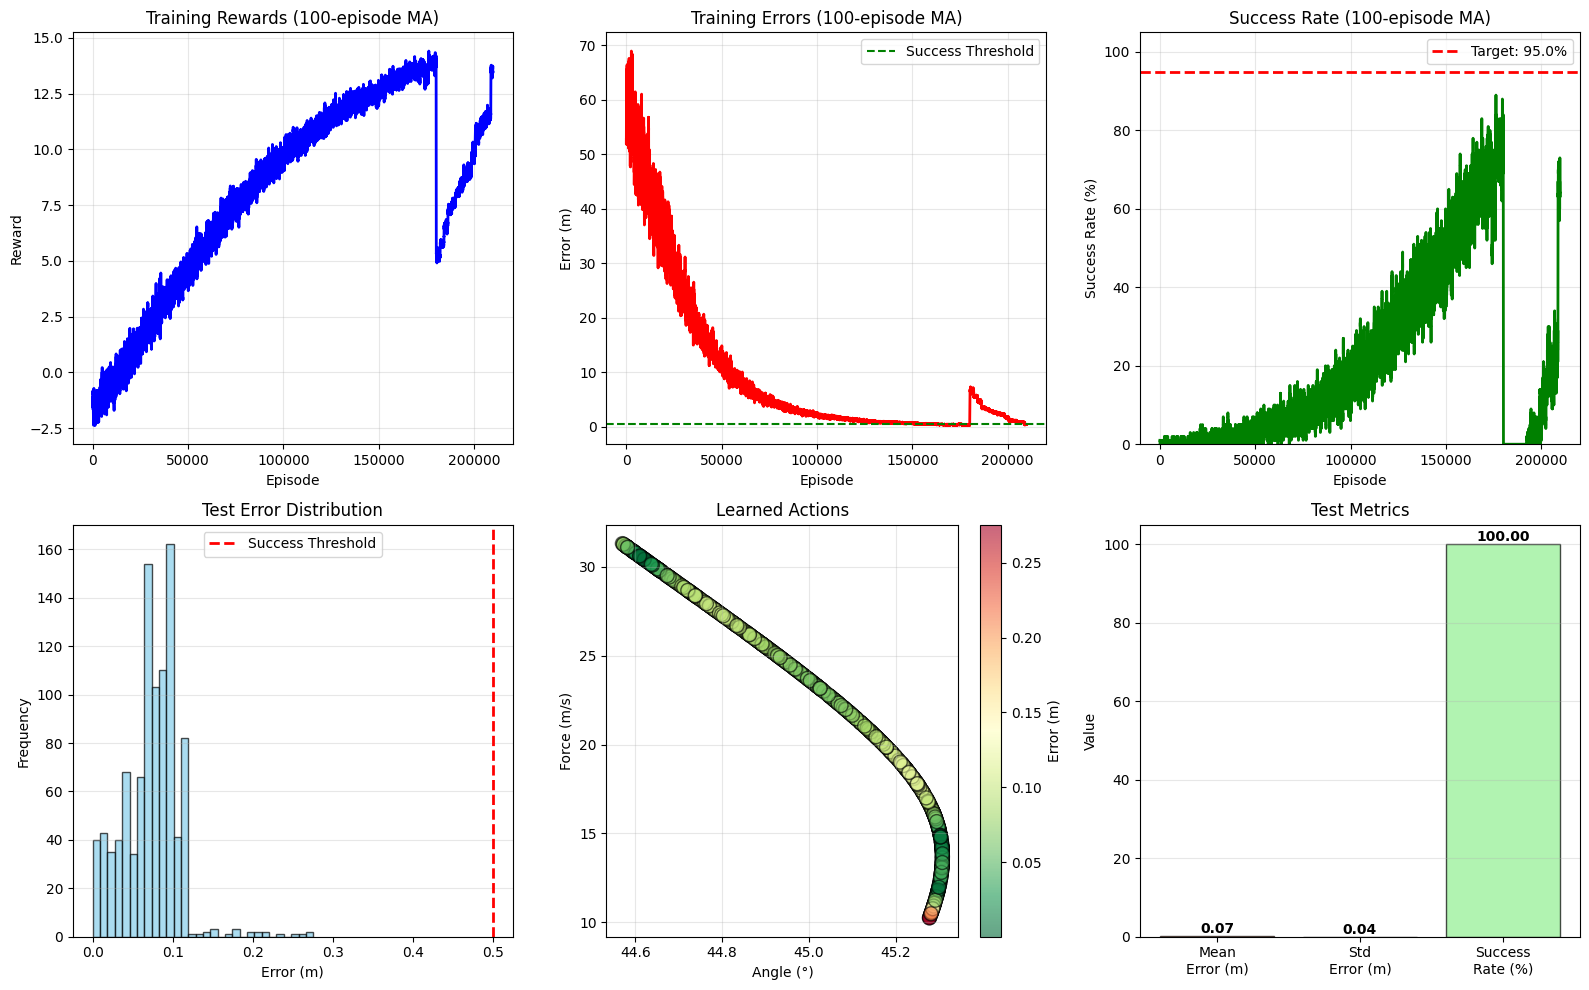

In [37]:
# Test the agent
model = PPO.load("ppo_projectile_best_model", env=env)
test_results = test_agent(model, env, num_tests=1000)

# Visualize results
visualize_results(callback, test_results)

In [ ]:
env = Projectile1DEnv()

model = PPO.load("ppo_projectile_best_model", env=env)
# Test the agent
test_results = test_agent(model, env, num_tests=100000)

print("\n" + "=" * 70)
print("✓ COMPLETE!")
print(f"✓ Final Success Rate: {test_results['success_rate']:.1f}%")
print(f"✓ Final Mean Error: {test_results['mean_error']:.2f}m")
print("=" * 70)


TESTING TRAINED AGENT

Test Results (100000 trials):
  Mean Error: 0.16 ± 0.09m
  Success Rate: 41.4%
  Min Error: 0.00m
  Max Error: 0.30m

----------------------------------------------------------------------
Example Predictions:
  Target (m) |  Angle (°) |  Force (m/s) |  Actual (m) |  Error (m)
----------------------------------------------------------------------
        15.0 |       44.8 |        12.10 |       14.92 |       0.08
        30.0 |       44.9 |        17.18 |       30.09 |       0.09
        50.0 |       44.8 |        22.17 |       50.09 |       0.09
        70.0 |       44.8 |        26.25 |       70.21 |       0.21
        90.0 |       44.8 |        29.76 |       90.30 |       0.30

✓ COMPLETE!
✓ Final Success Rate: 41.4%
✓ Final Mean Error: 0.16m


In [11]:
env.target_distance=90
obs1=np.array([env.target_distance/env.max_distance],dtype=np.float32)
# obs, _ = env.reset()

In [12]:
action, _ = model.predict(obs1, deterministic=True)

In [13]:
action_, _, _, _, info = env.step(action)
        
info

{'angle': 48.57141876220703,
 'force': 29.812620162963867,
 'actual_distance': 89.89750671386719,
 'target_distance': 90.0,
 'error': 0.1024932861328125,
 'success': False}

In [14]:
def plot_current_trajectory(model, env):
    """
    Plot trajectory for the current target in env
    Uses whatever target is already set in env.target_distance
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Use current target distance
    target_dist = env.target_distance
    obs = np.array([target_dist / env.max_distance], dtype=np.float32)
    
    # Get model's prediction
    action, _ = model.predict(obs, deterministic=True)
    _, _, _, _, info = env.step(action)
    
    angle = info['angle']
    force = info['force']
    actual_dist = info['actual_distance']
    error = info['error']
    
    # Calculate trajectory
    angle_rad = np.deg2rad(angle)
    t_flight = (2 * force * np.sin(angle_rad)) / env.g
    t_points = np.linspace(0, t_flight, 100)
    
    x = force * np.cos(angle_rad) * t_points
    y = force * np.sin(angle_rad) * t_points - 0.5 * env.g * t_points**2
    
    # Create plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot trajectory
    ax.plot(x, y, 'b-', linewidth=3, label='Trajectory')
    
    # Launch point
    ax.plot(0, 0, 'go', markersize=15, label='Launch Point', zorder=5)
    
    # Landing point
    ax.plot(actual_dist, 0, 'ro', markersize=12, 
            label=f'Landing: {actual_dist:.2f}m', zorder=5)
    
    # Target zone
    target_zone = plt.Rectangle(
        (target_dist - env.tolerance, -1),
        2 * env.tolerance, 
        1,
        color='green', alpha=0.3, label=f'Target Zone'
    )
    ax.add_patch(target_zone)
    ax.axvline(x=target_dist, color='green', linestyle='--', 
               linewidth=2, alpha=0.6, label=f'Target: {target_dist:.2f}m')
    
    # Apex
    # apex_idx = np.argmax(y)
    # ax.plot(x[apex_idx], y[apex_idx], 'y*', markersize=20, 
    #         label=f'Apex: {y[apex_idx]:.2f}m', zorder=5)
    
    # Ground
    ax.axhline(y=0, color='brown', linewidth=3, alpha=0.7)
    
    # Title
    success = "✓ HIT!" if error < env.tolerance else "✗ MISS"
    color = 'green' if error < env.tolerance else 'red'
    ax.set_title(
        f'{success} | Target: {target_dist:.2f}m | Error: {error:.2f}m\n'
        f'Launch Angle: {angle:.2f}° | Launch Velocity: {force:.2f}m/s',
        fontsize=14, fontweight='bold', color=color, pad=20
    )
    
    # Labels
    ax.set_xlabel('Horizontal Distance (m)', fontsize=12)
    ax.set_ylabel('Height (m)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='upper right')
    
    # Limits
    max_x = max(target_dist * 1.1, actual_dist * 1.1)
    ax.set_xlim(-5, max_x)
    ax.set_ylim(-2, np.max(y) * 1.2)
    
    plt.tight_layout()
    plt.savefig('current_trajectory.png', dpi=150, bbox_inches='tight')
    print(f"\n✓ Trajectory plot saved: Target={target_dist:.2f}m, Error={error:.2f}m")
    plt.show()


✓ Trajectory plot saved: Target=90.00m, Error=0.10m


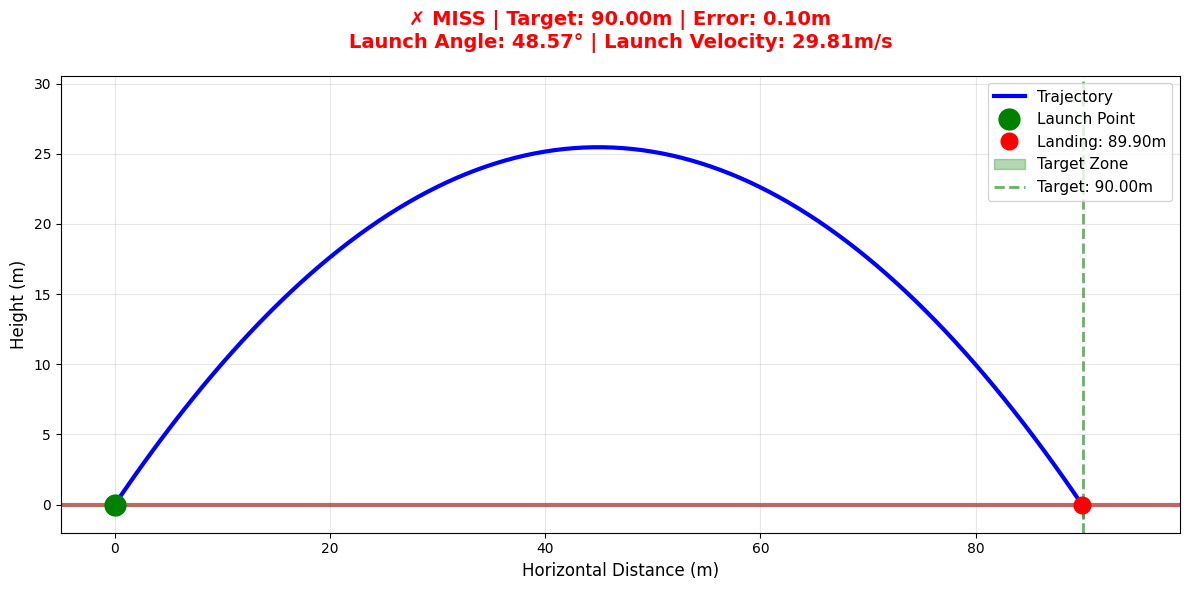

In [15]:
plot_current_trajectory(model, env)